# Laboratorio 1 - Series de Tiempo
## Analisis Exploratorio de Datos (EDA)
### Ingreso de viajeros internacionales a Guatemala (2009 - jun 2026)

CC3084 - Data Science, UVG

Este notebook cubre el punto 1 del laboratorio: analisis exploratorio del conjunto de datos.

## 1. Carga de datos

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("ok")

ok


In [29]:

df = pd.read_csv('Base_Migracion_2009-2026jun.csv', sep=';', encoding='utf-8-sig')
print(df.shape)
df.head()

(161036, 13)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


El dataset tiene 161,036 filas y 13 columnas. Cada fila es una combinacion de
Año, Mes, Via, Frontera, Pais y Tipo de Viajero, con la cantidad de viajeros correspondiente.

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


Todas las columnas categoricas se leyeron como texto y `Viajero` como numero decimal (float).
Hay que revisar por que `Viajero` no es entero.

In [31]:
no_entero = df[df['Viajero'] % 1 != 0]
print(f"Filas con valores no enteros en Viajero: {len(no_entero)} de {len(df)}")
no_entero[['Año','País','Tipo de Viajero','Viajero']].head()

Filas con valores no enteros en Viajero: 43145 de 161036


,Año,País,Tipo de Viajero,Viajero
172,2009,Cruceristas,Cruceristas,6518.968580
182,2009,Cruceristas,Cruceristas,6051.031420
260,2009,Canadá,Excursionista,4.656522
261,2009,Canadá,Turista,83.817391
262,2009,Canadá,Viajero,64.526087


Cerca del 27% de las filas tienen decimales en `Viajero`. Esto ocurre sobre todo en la categoria
Cruceristas y en paises con pocos viajeros, probablemente porque la cifra reportada es un estimado o un
prorateo (por ejemplo reparto de un total entre categorias). No lo consideramos un error: son datos
validos, solo que no siempre representan conteos enteros exactos.

## 2. Valores faltantes, duplicados y valores atipicos

### 2.1 Valores faltantes

In [32]:
df.isna().sum()

Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

No hay valores nulos en ninguna columna. El dataset viene completo en ese sentido.

### 2.2 Duplicados

In [33]:
print("Filas identicas en todas las columnas:", df.duplicated().sum())

llaves = ['Año','Mes cod','Vía','Frontera','País','Tipo de Viajero']
print("Filas con la misma combinacion Año-Mes-Via-Frontera-Pais-Tipo:", df.duplicated(subset=llaves).sum())

Filas identicas en todas las columnas: 0
Filas con la misma combinacion Año-Mes-Via-Frontera-Pais-Tipo: 22


No hay filas exactamente duplicadas. Sin embargo hay 22 filas que comparten la misma llave
(Año, Mes, Via, Frontera, Pais, Tipo de Viajero) pero con un valor distinto de `Viajero`.

In [34]:
dup = df[df.duplicated(subset=llaves, keep=False)].sort_values(llaves)
dup[['Año','Mes','Vía','Frontera','País','Tipo de Viajero','Viajero']].head(10)

,Año,Mes,Vía,Frontera,País,Tipo de Viajero,Viajero
130128,2020,Dic,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,3.0
130129,2020,Dic,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,1.0
131981,2021,May,Aérea,01 La Aurora,Federación de Rusia,Turista,44.0
131982,2021,May,Aérea,01 La Aurora,Federación de Rusia,Turista,223.0
132717,2021,Jun,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,4.0
132718,2021,Jun,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,1.0
133281,2021,Jul,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,7.0
133282,2021,Jul,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,13.0
138849,2022,Abr,Aérea,01 La Aurora,Colombia,Turista,2610.0
138850,2022,Abr,Aérea,01 La Aurora,Colombia,Turista,1051.0


Son casos aislados (menos del 0.01% de las filas) donde parece haber dos registros para el mismo
mes y pais, posiblemente por una correccion o un doble registro en la fuente original. Como al construir
las series de tiempo vamos a sumar `Viajero` por mes, estos casos no generan un problema real: simplemente
se suman ambos valores. No se eliminan filas porque no hay evidencia de que uno de los dos registros sea
un error.

### 2.3 Valores atipicos

In [35]:
df['Viajero'].describe()

count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035070
Name: Viajero, dtype: float64

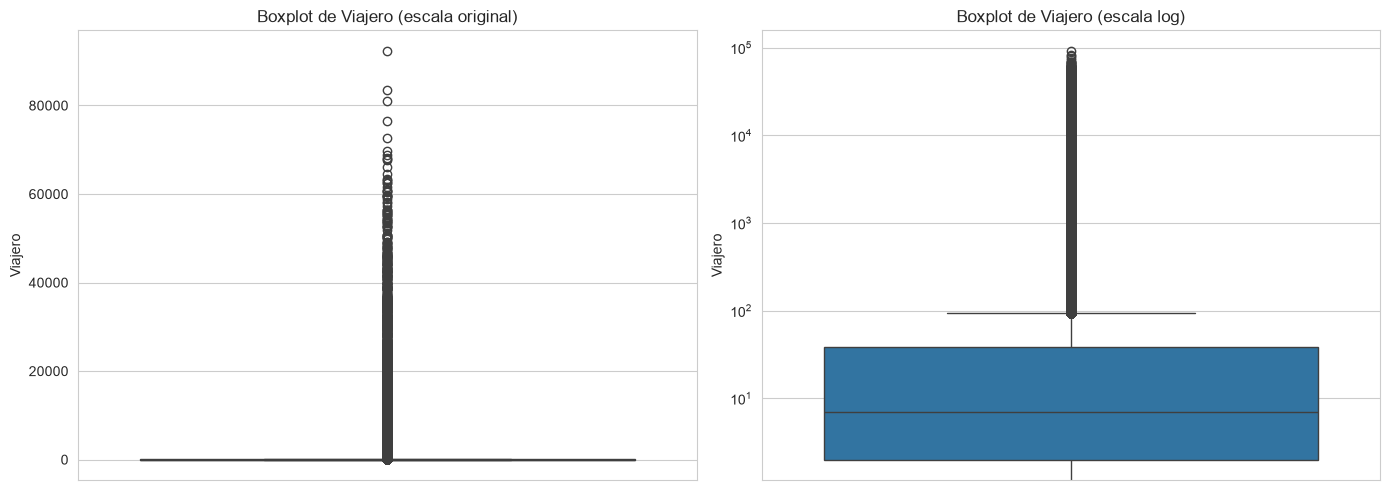

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, y='Viajero', ax=ax[0])
ax[0].set_title('Boxplot de Viajero (escala original)')
sns.boxplot(data=df, y='Viajero', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Boxplot de Viajero (escala log)')
plt.tight_layout()
plt.show()

La distribucion de `Viajero` esta muy sesgada a la derecha: la mediana es 7 viajeros por registro
pero el maximo llega a mas de 92,000. Esto es esperable porque cada fila mezcla paises con muchisimo
turismo (Estados Unidos, El Salvador) con paises que casi no envian viajeros (Islas Cook, por ejemplo).
No son errores, son la naturaleza de los datos: hay que tenerlo en cuenta al momento de resumir por pais
o region, usando sumas totales en vez de promedios por fila.

In [37]:
outliers_por_tipo = df.groupby('Tipo de Viajero')['Viajero'].describe()
outliers_por_tipo

,count,mean,std,min,25%,50%,75%,max
Tipo de Viajero,,,,,,,,
Cruceristas,204.0,5413.735294,4225.763359,85.0,2094.0,4454.906604,7173.500000,21680.93357
Excursionista,19730.0,459.664690,1833.670984,0.0,2.0,10.000000,80.255455,38463.02606
Turista,117912.0,319.244255,2611.324160,0.0,2.0,6.000000,33.000000,83511.00000
Viajero,23190.0,192.825451,1281.234973,0.0,2.0,8.181818,44.000000,92336.03507


Separado por tipo de viajero se ve mejor: Turista tiene el rango mas amplio (hasta paises grandes
como EE.UU. en meses de alta afluencia), mientras Cruceristas tiene menos registros pero valores altos
concentrados (llegadas de cruceros completos). Ninguno de estos valores altos se ve como un error de
captura, son consistentes con paises/meses de alta afluencia conocida.

## 3. Nota sobre la categoria "Viajero"

Segun el enunciado del laboratorio, entre 2022 y 2023 la categoria de tipo de viajero "Viajero" cambio
de definicion (dejo de incluir comercio fronterizo y transito de alta frecuencia). Esto se confirma abajo:

In [38]:
tipo_anual = df.groupby(['Año','Tipo de Viajero'])['Viajero'].sum().unstack()
tipo_anual

Tipo de Viajero,Cruceristas,Excursionista,Turista,Viajero
Año,,,,
2009,81346.000000,2.640982e+05,1.616085e+06,6.724687e+04
2010,72488.000000,3.000031e+05,1.704781e+06,7.562685e+04
2011,72350.000000,3.241871e+05,1.755528e+06,7.939150e+04
2012,72846.000000,3.593042e+05,1.780237e+06,8.742810e+04
2013,71690.000000,3.791146e+05,1.910588e+06,7.077623e+04
2014,70601.000000,4.492579e+05,2.210919e+06,3.182365e+04
2015,77195.000000,5.051244e+05,2.412762e+06,4.656154e+04
2016,103712.000001,3.596031e+05,2.637424e+06,3.954781e+05
2017,129063.000004,5.828400e+05,2.724811e+06,4.847460e+05


Se ve claramente la caida de la categoria "Viajero" en 2023 (de ~1,060,806 en 2022 a ~330,882 en
2023) y que "Cruceristas" deja de reportarse como categoria separada a partir de 2023 (columna vacia).
Por eso, para todo el analisis de comportamiento temporal usamos **Turista + Excursionista**, que se
mantienen consistentes en toda la serie 2009-2026, tal como recomienda el enunciado.

In [39]:
df['metrica_principal'] = df['Tipo de Viajero'].isin(['Turista','Excursionista'])
print("Filas usadas en Turista+Excursionista:", df['metrica_principal'].sum(), "de", len(df))

Filas usadas en Turista+Excursionista: 137642 de 161036


## 4. Comportamiento temporal del numero de viajeros

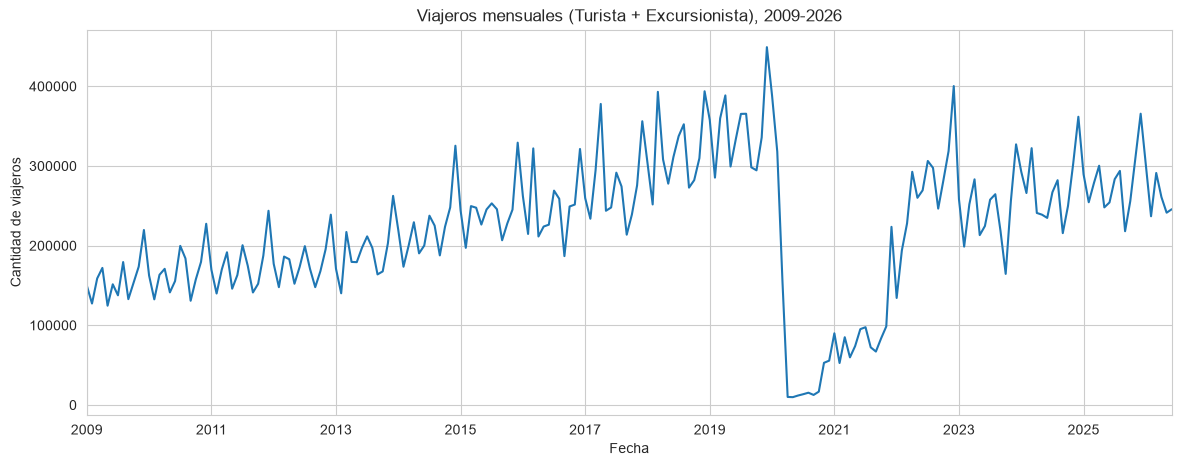

In [40]:
df['fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')

serie_total = (df[df['metrica_principal']]
               .groupby('fecha')['Viajero']
               .sum())

serie_total.plot(figsize=(14,5), title='Viajeros mensuales (Turista + Excursionista), 2009-2026')
plt.ylabel('Cantidad de viajeros')
plt.xlabel('Fecha')
plt.show()

Se observa una tendencia creciente desde 2009 hasta 2019, una caida abrupta en 2020 por la
pandemia de COVID-19, una recuperacion lenta en 2021-2022 y una vuelta a niveles cercanos a los de
antes de la pandemia entre 2023 y 2026. Tambien se nota un patron estacional dentro de cada año
(picos y valles que se repiten), que se vera con mas detalle al analizar la serie a fondo en la
siguiente entrega.

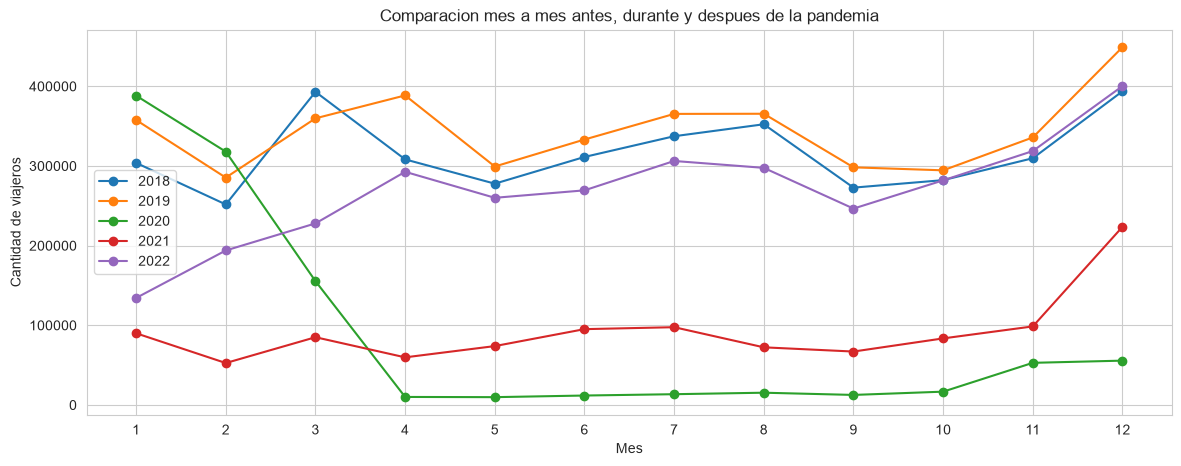

In [41]:
fig, ax = plt.subplots(figsize=(14,5))
for anio in [2018, 2019, 2020, 2021, 2022]:
    sub = serie_total[serie_total.index.year == anio]
    ax.plot(sub.index.month, sub.values, marker='o', label=str(anio))
ax.set_xticks(range(1,13))
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de viajeros')
ax.set_title('Comparacion mes a mes antes, durante y despues de la pandemia')
ax.legend()
plt.show()

Este grafico muestra bien el efecto de la pandemia: 2018 y 2019 tienen un comportamiento
similar y estable, 2020 se desploma a partir de marzo (cuando cerraron fronteras), 2021 se mantiene
muy bajo casi todo el año, y 2022 empieza a recuperarse aunque sin llegar todavia a niveles de 2019.

## 5. Paises con mayor cantidad de viajeros

In [42]:
top_paises = (df[df['metrica_principal']]
              .groupby('País')['Viajero']
              .sum()
              .sort_values(ascending=False)
              .head(10))

top_paises

País
El Salvador                  1.407914e+07
Guatemala                    1.387039e+07
Estados Unidos de América    6.965680e+06
Honduras                     2.520974e+06
México                       1.678423e+06
Belice                       9.161011e+05
Costa Rica                   8.602407e+05
Nicaragua                    8.111454e+05
Colombia                     5.494947e+05
Canadá                       5.167079e+05
Name: Viajero, dtype: float64

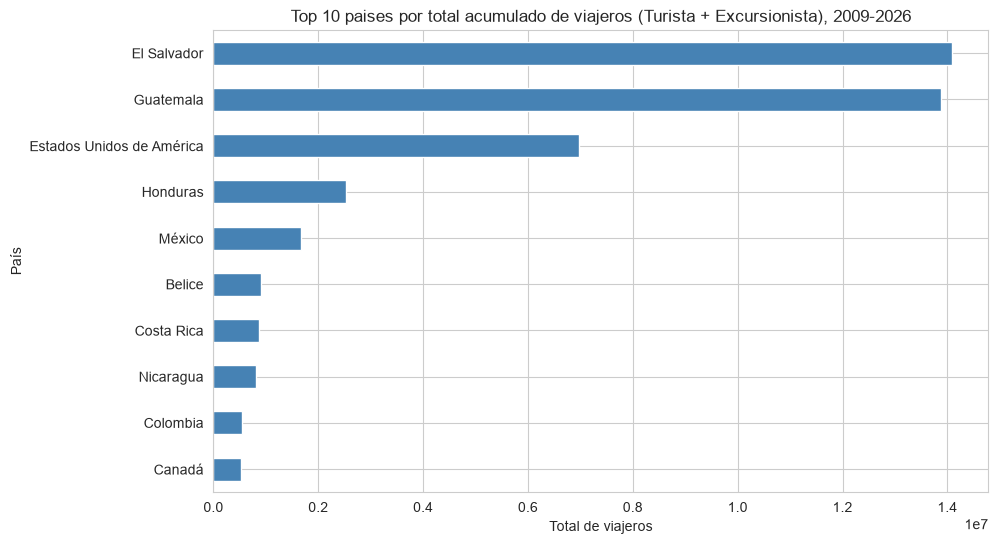

In [43]:
top_paises.sort_values().plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 10 paises por total acumulado de viajeros (Turista + Excursionista), 2009-2026')
plt.xlabel('Total de viajeros')
plt.show()

El Salvador, Honduras y Estados Unidos concentran la mayor parte del turismo acumulado, lo cual
tiene sentido porque son los paises vecinos con mas movilidad terrestre hacia Guatemala, ademas de ser
el mercado de largo alcance mas grande (EE.UU.). Esto sugiere que buena parte del "turismo" en estos
datos en realidad corresponde a movimiento fronterizo regional.

## 6. Regiones con mayor cantidad de viajeros

In [44]:
top_regiones = (df[df['metrica_principal']]
                .groupby('Región dos')['Viajero']
                .sum()
                .sort_values(ascending=False))

top_regiones

Región dos
América Del Centro             3.328393e+07
América Del Norte              9.160810e+06
Europa                         2.149271e+06
América Del Sur y el Caribe    1.413590e+06
Asia                           4.103335e+05
Oceanía                        1.355054e+05
Oriente Medio                  1.337352e+05
Otros Paises Del Mundo         2.391430e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

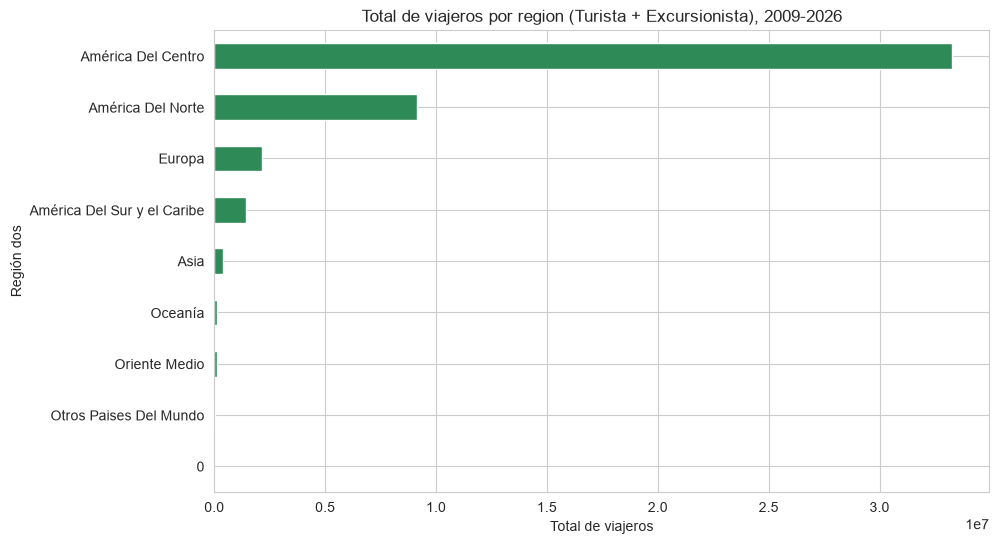

In [45]:
top_regiones.sort_values().plot(kind='barh', figsize=(10,6), color='seagreen')
plt.title('Total de viajeros por region (Turista + Excursionista), 2009-2026')
plt.xlabel('Total de viajeros')
plt.show()

America del Centro domina por mucho el total, seguida de America del Norte. Esto confirma lo
visto con los paises: el turismo de Guatemala es mayormente regional (Centroamerica), con Estados
Unidos y Canada como el principal mercado de fuera de la region.

## 7. Vias de ingreso y fronteras mas utilizadas

In [46]:
top_vias = (df[df['metrica_principal']]
            .groupby('Vía')['Viajero']
            .sum()
            .sort_values(ascending=False))

top_vias

Vía
Terrestre    2.759225e+07
Aérea        1.901942e+07
Marítima     1.002410e+05
Name: Viajero, dtype: float64

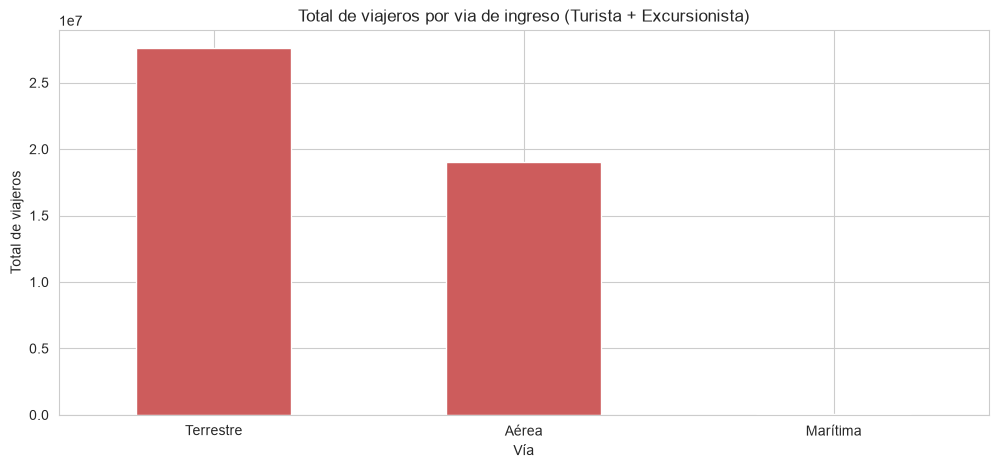

In [47]:
top_vias.plot(kind='bar', color='indianred')
plt.title('Total de viajeros por via de ingreso (Turista + Excursionista)')
plt.ylabel('Total de viajeros')
plt.xticks(rotation=0)
plt.show()

La via Terrestre es la mas utilizada, seguida de cerca por la Aerea. La via Maritima practicamente
no aparece en Turista+Excursionista porque los cruceros se registran bajo el tipo de viajero
"Cruceristas", que es una categoria distinta. Esto es importante: si se construye la serie de la via
Maritima con esta metrica, va a salir casi en cero, y hay que aclararlo en el analisis.

In [48]:
top_fronteras = (df[df['metrica_principal']]
                 .groupby('Frontera')['Viajero']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

top_fronteras

Frontera
01 La Aurora                     1.898998e+07
07 Valle Nuevo                   1.014305e+07
09 San Cristóbal                 4.183632e+06
08 Pedro de Alvarado             3.764229e+06
10 La Ermita (Nueva Anguiatú)    2.587072e+06
20 Melchor de Mencos             1.782864e+06
13 El Cinchado / El Corinto      1.213485e+06
11 Agua Caliente                 9.224195e+05
12 El Florido                    9.103735e+05
15 El Carmen                     8.526631e+05
Name: Viajero, dtype: float64

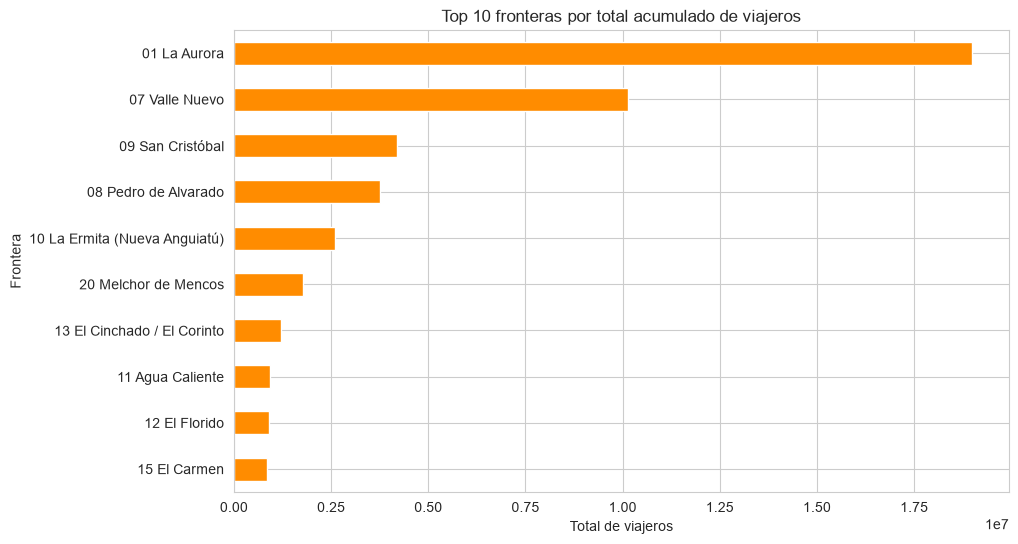

In [49]:
top_fronteras.sort_values().plot(kind='barh', figsize=(10,6), color='darkorange')
plt.title('Top 10 fronteras por total acumulado de viajeros')
plt.xlabel('Total de viajeros')
plt.show()

La Aurora (aeropuerto principal) y los pasos fronterizos terrestres con El Salvador y Honduras
concentran la mayoria del ingreso de viajeros, consistente con lo que ya se vio por pais y por via.

## 8. Estadisticas descriptivas adicionales

In [50]:
resumen_anual = (df[df['metrica_principal']]
                 .groupby('Año')['Viajero']
                 .sum())

resumen_anual

Año
2009    1.880183e+06
2010    2.004784e+06
2011    2.079715e+06
2012    2.139541e+06
2013    2.289703e+06
2014    2.660177e+06
2015    2.917886e+06
2016    2.997027e+06
2017    3.307651e+06
2018    3.793761e+06
2019    4.132251e+06
2020    1.059770e+06
2021    1.098964e+06
2022    3.229329e+06
2023    2.917827e+06
2024    3.274436e+06
2025    3.352289e+06
2026    1.576619e+06
Name: Viajero, dtype: float64

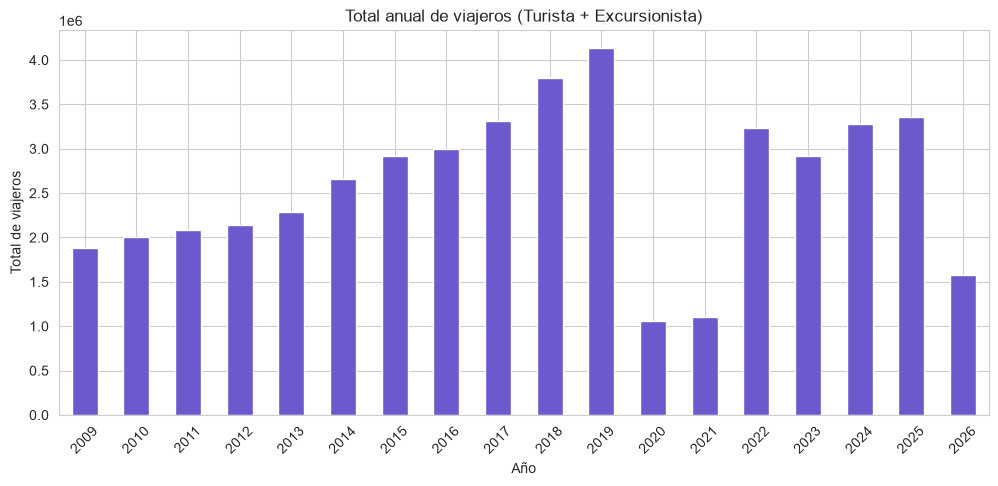

In [51]:
resumen_anual.plot(kind='bar', figsize=(12,5), color='slateblue')
plt.title('Total anual de viajeros (Turista + Excursionista)')
plt.ylabel('Total de viajeros')
plt.xticks(rotation=45)
plt.show()

Nota: 2009 y 2026 son años parciales en cuanto a lo que se ve en el grafico de barras (2026 solo
llega hasta junio), asi que no son comparables directamente contra un año completo como 2019.

In [52]:
crecimiento = resumen_anual.pct_change() * 100
crecimiento.round(1)

Año
2009      NaN
2010      6.6
2011      3.7
2012      2.9
2013      7.0
2014     16.2
2015      9.7
2016      2.7
2017     10.4
2018     14.7
2019      8.9
2020    -74.4
2021      3.7
2022    193.9
2023     -9.6
2024     12.2
2025      2.4
2026    -53.0
Name: Viajero, dtype: float64

La caida mas fuerte es 2020 (-73% aprox. vs 2019), y la recuperacion mas fuerte es 2021 a 2022
cuando se reabren fronteras casi por completo. De 2023 en adelante el crecimiento se estabiliza en
tasas mas moderadas, cercanas a las de antes de la pandemia.

In [53]:
df[df['metrica_principal']]['Viajero'].describe()

count    137642.000000
mean        339.372524
std        2515.137946
min           0.000000
25%           2.000000
50%           7.000000
75%          37.000000
max       83511.000000
Name: Viajero, dtype: float64

Podemos concluir para el EDA que el dataset esta limpio (sin nulos, sin duplicados reales), tiene algunos valores
decimales que son validos y no errores, y muestra con claridad tres cosas: una tendencia de crecimiento
de largo plazo, un quiebre fuerte por la pandemia en 2020-2021, y una concentracion del turismo en
paises y fronteras centroamericanas. Estos hallazgos ya dan una buena base para construir y modelar
las series de tiempo en la siguiente parte del laboratorio.

## 9. Division en entrenamiento y prueba (70/30)

El corte se hace por tiempo, no al azar, porque en series de tiempo el orden importa: no tiene
sentido "prueba" un modelo con meses que quedaron antes que los de entrenamiento.

Tomamos el 70% inicial de los meses (2009-01 a 2021-03, 147 meses) como entrenamiento, y el 30%
restante (2021-04 a 2026-06, 63 meses) como prueba.

In [54]:
fecha_corte = '2021-04-01'

df_train = df[df['fecha'] < fecha_corte].copy()
df_test = df[df['fecha'] >= fecha_corte].copy()

print("Entrenamiento:", df_train['fecha'].min(), "a", df_train['fecha'].max(), "-", df_train['fecha'].nunique(), "meses")
print("Prueba:       ", df_test['fecha'].min(), "a", df_test['fecha'].max(), "-", df_test['fecha'].nunique(), "meses")
print(f"Proporcion train: {df_train['fecha'].nunique()/df['fecha'].nunique():.1%}")

Entrenamiento: 2009-01-01 00:00:00 a 2021-03-01 00:00:00 - 147 meses
Prueba:        2021-04-01 00:00:00 a 2026-06-01 00:00:00 - 63 meses
Proporcion train: 70.0%


In [55]:
df_train.to_csv('train_raw.csv', index=False)
df_test.to_csv('test_raw.csv', index=False)
print("Archivos guardados: train_raw.csv, test_raw.csv")

Archivos guardados: train_raw.csv, test_raw.csv
